# YOLO + PyTorch Animal Classification

This notebook demonstrates animal classification using YOLOv8 and PyTorch on a diverse wildlife dataset.

In [5]:
import os
import shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import json
import warnings

warnings.filterwarnings('ignore')

# Check GPU availability
print(f"GPU Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    print(f"PyTorch Version: {torch.__version__}")
    print(f"CUDA Version: {torch.version.cuda}")

GPU Available: True
GPU Device: NVIDIA GeForce RTX 4050 Laptop GPU
PyTorch Version: 2.5.1+cu121
CUDA Version: 12.1


## 1. Setup and Configuration

In [6]:
# Configuration
BASE_DIR = Path('models/datasets/animals')
SAVE_DIR = Path('models/saved_models')
SAVE_DIR.mkdir(parents=True, exist_ok=True)

TRAIN_DIR = SAVE_DIR / 'train'
VAL_DIR = SAVE_DIR / 'val'
TEST_DIR = SAVE_DIR / 'test'

# Create directories
for dir_path in [TRAIN_DIR, VAL_DIR, TEST_DIR]:
    dir_path.mkdir(parents=True, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 25
LEARNING_RATE = 0.001
IMAGE_SIZE = (224, 224)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"Base Directory: {BASE_DIR}")
print(f"Save Directory: {SAVE_DIR}")
print(f"Device: {DEVICE}")
print(f"Image Size: {IMAGE_SIZE}")
print(f"Batch Size: {BATCH_SIZE}")

Base Directory: models\datasets\animals
Save Directory: models\saved_models
Device: cuda
Image Size: (224, 224)
Batch Size: 32


## 2. Dataset Preparation

In [7]:
# Get all animal classes
animal_classes = [d for d in BASE_DIR.iterdir() if d.is_dir() and d.name != 'test']
num_classes = len(animal_classes)

print(f"Number of Animal Classes: {num_classes}")
print(f"Animal Classes: {sorted([cls.name for cls in animal_classes])}")

# Count images per class
class_stats = {}
for animal_dir in animal_classes:
    image_files = list(animal_dir.glob('*.jpg')) + list(animal_dir.glob('*.png')) + list(animal_dir.glob('*.jpeg'))
    class_stats[animal_dir.name] = len(image_files)

# Display statistics
print("\nDataset Statistics:")
print(f"{'Class':<20} {'Images':<10}")
print("-" * 30)
for class_name in sorted(class_stats.keys()):
    print(f"{class_name:<20} {class_stats[class_name]:<10}")
print(f"{'Total':<20} {sum(class_stats.values()):<10}")

Number of Animal Classes: 90
Animal Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wombat', 'woodpecker', 'zebra']

Dataset Statistics:
Class        

In [8]:
# Split dataset into train, validation, and test
def organize_dataset(source_base, train_dir, val_dir, test_dir, train_ratio=0.7, val_ratio=0.15):
    """Organize dataset into train/val/test splits with small-sample safeguards."""
    
    # Clear existing directories
    for dir_path in [train_dir, val_dir, test_dir]:
        if dir_path.exists():
            shutil.rmtree(dir_path)
        dir_path.mkdir(parents=True, exist_ok=True)
    
    rng = np.random.default_rng(42)
    
    for animal_class in source_base.iterdir():
        if not animal_class.is_dir() or animal_class.name == 'test':
            continue
        
        # Create class subdirectories
        for split_dir in [train_dir, val_dir, test_dir]:
            (split_dir / animal_class.name).mkdir(parents=True, exist_ok=True)
        
        # Get all images
        images = list(animal_class.glob('*.jpg')) + \
                 list(animal_class.glob('*.png')) + \
                 list(animal_class.glob('*.jpeg'))
        
        if len(images) == 0:
            continue
        
        # Deterministic shuffle
        images = list(images)
        rng.shuffle(images)
        n = len(images)
        
        # Small-sample handling
        if n == 1:
            train_imgs, val_imgs, test_imgs = images, [], []
        elif n == 2:
            train_imgs, val_imgs, test_imgs = images[:1], [], images[1:]
        elif n == 3:
            train_imgs, val_imgs, test_imgs = images[:2], images[2:], []
        else:
            n_train = max(1, int(round(train_ratio * n)))
            n_remaining = n - n_train
            if n_remaining <= 0:
                n_train = n - 2
                n_remaining = 2
            n_val = max(1, int(round(val_ratio * n)))
            if n_val >= n_remaining:
                n_val = max(1, n_remaining - 1)
            n_test = n - n_train - n_val
            if n_test <= 0:
                n_test = 1
                n_val = n - n_train - n_test
            
            train_imgs = images[:n_train]
            val_imgs = images[n_train:n_train + n_val]
            test_imgs = images[n_train + n_val:]
        
        # Copy images to split directories
        for img in train_imgs:
            shutil.copy(img, train_dir / animal_class.name / img.name)
        for img in val_imgs:
            shutil.copy(img, val_dir / animal_class.name / img.name)
        for img in test_imgs:
            shutil.copy(img, test_dir / animal_class.name / img.name)
    
    print("Dataset organized successfully!")

organize_dataset(BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

Dataset organized successfully!


In [9]:
# Ensure split folders exist and are populated before creating datasets
def ensure_splits_ready():
    if not BASE_DIR.exists():
        raise FileNotFoundError(f"BASE_DIR does not exist: {BASE_DIR}")
    required_dirs = [TRAIN_DIR, VAL_DIR, TEST_DIR]
    needs_build = False
    for split_dir in required_dirs:
        # If split dir is missing or has no class subfolders with images, rebuild
        if not split_dir.exists():
            needs_build = True
            break
        subdirs = [p for p in split_dir.iterdir() if p.is_dir()]
        has_images = any(any(p.glob('*.jpg')) or any(p.glob('*.png')) or any(p.glob('*.jpeg')) for p in subdirs)
        if not subdirs or not has_images:
            needs_build = True
            break
    
    if needs_build:
        print("Split folders empty or missing; rebuilding from BASE_DIR ...")
        organize_dataset(BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)
    else:
        print("Split folders already populated; skipping rebuild.")
        for split_dir in required_dirs:
            counts = {p.name: len(list(p.glob('*.jpg')) + list(p.glob('*.png')) + list(p.glob('*.jpeg'))) for p in split_dir.iterdir() if p.is_dir()}
            print(f"{split_dir.name}: {sum(counts.values())} images across {len(counts)} classes")
            
# Run the readiness check before creating ImageFolder datasets
ensure_splits_ready()

Split folders already populated; skipping rebuild.
train: 3780 images across 90 classes
val: 810 images across 90 classes
test: 810 images across 90 classes


In [10]:
# Define image transforms
train_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(IMAGE_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Sanity check: ensure split folders contain images
def count_images(root):
    exts = ['*.jpg', '*.jpeg', '*.png', '*.bmp', '*.tif', '*.tiff', '*.webp', '*.ppm', '*.pgm']
    return sum(len(list(root.rglob(ext))) for ext in exts)

train_count = count_images(TRAIN_DIR)
val_count = count_images(VAL_DIR)
test_count = count_images(TEST_DIR)

# Rebuild splits automatically if they are empty
if min(train_count, val_count, test_count) == 0:
    print("Split folders empty; rebuilding from BASE_DIR ...")
    ensure_splits_ready()
    # Re-count after rebuilding
    train_count = count_images(TRAIN_DIR)
    val_count = count_images(VAL_DIR)
    test_count = count_images(TEST_DIR)

# If still empty, synthesize a tiny dummy dataset so the pipeline can run
if min(train_count, val_count, test_count) == 0:
    print("No images found; creating a small dummy dataset for sanity checks ...")
    
    def _create_dummy_images(base_dir, num_per_class=3):
        """Create random RGB images for each class directory to avoid empty splits."""
        # Use existing class directories; if none, create two placeholder classes
        existing_classes = [p.name for p in base_dir.iterdir() if p.is_dir() and p.name != 'test']
        if not existing_classes:
            existing_classes = ['class0', 'class1']
            for cls in existing_classes:
                (base_dir / cls).mkdir(parents=True, exist_ok=True)
        
        for cls in existing_classes:
            cls_dir = base_dir / cls
            cls_dir.mkdir(parents=True, exist_ok=True)
            current_imgs = len(list(cls_dir.glob('dummy_*.png')))
            needed = max(num_per_class - current_imgs, 0)
            for i in range(needed):
                arr = np.random.randint(0, 256, (IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
                img = Image.fromarray(arr)
                img.save(cls_dir / f"dummy_{current_imgs + i}.png")
    
    _create_dummy_images(BASE_DIR, num_per_class=3)
    organize_dataset(BASE_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)
    
    # Re-count after creating dummy data
    train_count = count_images(TRAIN_DIR)
    val_count = count_images(VAL_DIR)
    test_count = count_images(TEST_DIR)

if min(train_count, val_count, test_count) == 0:
    raise FileNotFoundError(
        f"No images found in split folders even after dummy generation.\n"
        f"Train: {train_count}, Val: {val_count}, Test: {test_count}.\n"
        f"Check BASE_DIR ({BASE_DIR}) and rerun organize_dataset."
    )

# Create datasets
train_dataset = ImageFolder(root=str(TRAIN_DIR), transform=train_transforms)
val_dataset = ImageFolder(root=str(VAL_DIR), transform=val_test_transforms)
test_dataset = ImageFolder(root=str(TEST_DIR), transform=val_test_transforms)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train Dataset Size: {len(train_dataset)}")
print(f"Validation Dataset Size: {len(val_dataset)}")
print(f"Test Dataset Size: {len(test_dataset)}")
print(f"Number of Classes: {len(train_dataset.classes)}")
print(f"Classes: {train_dataset.classes}")

Train Dataset Size: 3780
Validation Dataset Size: 810
Test Dataset Size: 810
Number of Classes: 90
Classes: ['antelope', 'badger', 'bat', 'bear', 'bee', 'beetle', 'bison', 'boar', 'butterfly', 'cat', 'caterpillar', 'chimpanzee', 'cockroach', 'cow', 'coyote', 'crab', 'crow', 'deer', 'dog', 'dolphin', 'donkey', 'dragonfly', 'duck', 'eagle', 'elephant', 'flamingo', 'fly', 'fox', 'goat', 'goldfish', 'goose', 'gorilla', 'grasshopper', 'hamster', 'hare', 'hedgehog', 'hippopotamus', 'hornbill', 'horse', 'hummingbird', 'hyena', 'jellyfish', 'kangaroo', 'koala', 'ladybugs', 'leopard', 'lion', 'lizard', 'lobster', 'mosquito', 'moth', 'mouse', 'octopus', 'okapi', 'orangutan', 'otter', 'owl', 'ox', 'oyster', 'panda', 'parrot', 'pelecaniformes', 'penguin', 'pig', 'pigeon', 'porcupine', 'possum', 'raccoon', 'rat', 'reindeer', 'rhinoceros', 'sandpiper', 'seahorse', 'seal', 'shark', 'sheep', 'snake', 'sparrow', 'squid', 'squirrel', 'starfish', 'swan', 'tiger', 'turkey', 'turtle', 'whale', 'wolf', 'wom

## 3. Build Custom YOLO-Inspired Model with PyTorch

In [11]:
# Custom ResNet-based classifier (inspired by YOLO backbone architecture)
class AnimalClassifier(nn.Module):
    def __init__(self, num_classes):
        super(AnimalClassifier, self).__init__()
        
        # Backbone with feature extraction layers
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

# Initialize model
model = AnimalClassifier(num_classes=num_classes).to(DEVICE)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Model Architecture:")
print(model)
print(f"\nTotal Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")

Model Architecture:
AnimalClassifier(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, 

## 4. Training Setup

In [12]:
# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'train_accuracy': [],
    'val_accuracy': []
}

def train_epoch(model, train_loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    for images, labels in tqdm(train_loader, desc='Training'):
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs.data, 1)
        running_corrects += torch.sum(preds == labels.data).item()
        total_samples += images.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    
    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """Validate for one epoch"""
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0
    
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc='Validating'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs.data, 1)
            running_corrects += torch.sum(preds == labels.data).item()
            total_samples += images.size(0)
    
    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects / total_samples
    
    return epoch_loss, epoch_acc

print("Training functions defined!")

Training functions defined!


## 5. Train the Model

In [13]:
# Train the model
best_val_acc = 0.0
best_model_path = SAVE_DIR / 'best_model.pth'

print("Starting training...")
print(f"Training for {EPOCHS} epochs\n")

for epoch in range(EPOCHS):
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print("-" * 50)
    
    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
    
    # Validate
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, DEVICE)
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_accuracy'].append(train_acc)
    history['val_accuracy'].append(val_acc)
    
    # Print metrics
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    print()
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_accuracy': val_acc,
            'class_names': train_dataset.classes
        }, best_model_path)
        print(f"✓ Best model saved with Val Acc: {val_acc:.4f}\n")

print("Training completed!")
print(f"Best Model Saved: {best_model_path}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Starting training...
Training for 25 epochs

Epoch 1/25
--------------------------------------------------


Validating: 100%|██████████| 26/26 [00:29<00:00,  1.14s/it]


Train Loss: 4.4760 | Train Acc: 0.0198
Val Loss: 4.3957 | Val Acc: 0.0272

✓ Best model saved with Val Acc: 0.0272

Epoch 2/25
--------------------------------------------------


Validating: 100%|██████████| 26/26 [00:09<00:00,  2.60it/s]


Train Loss: 4.3743 | Train Acc: 0.0283
Val Loss: 4.2011 | Val Acc: 0.0358

✓ Best model saved with Val Acc: 0.0358

Epoch 3/25
--------------------------------------------------


...

Train Loss: 3.8391 | Train Acc: 0.0802
Val Loss: 3.7613 | Val Acc: 0.1062

✓ Best model saved with Val Acc: 0.1062

Epoch 24/25
--------------------------------------------------


Validating: 100%|██████████| 26/26 [00:10<00:00,  2.50it/s]


Train Loss: 3.8474 | Train Acc: 0.0817
Val Loss: 3.7641 | Val Acc: 0.1173

✓ Best model saved with Val Acc: 0.1173

Epoch 25/25
--------------------------------------------------


Validating: 100%|██████████| 26/26 [00:12<00:00,  2.06it/s]

Train Loss: 3.8390 | Train Acc: 0.0825
Val Loss: 3.7804 | Val Acc: 0.1074

Training completed!
Best Model Saved: models\saved_models\best_model.pth
Best Validation Accuracy: 0.1173


## 6. Plot Training History

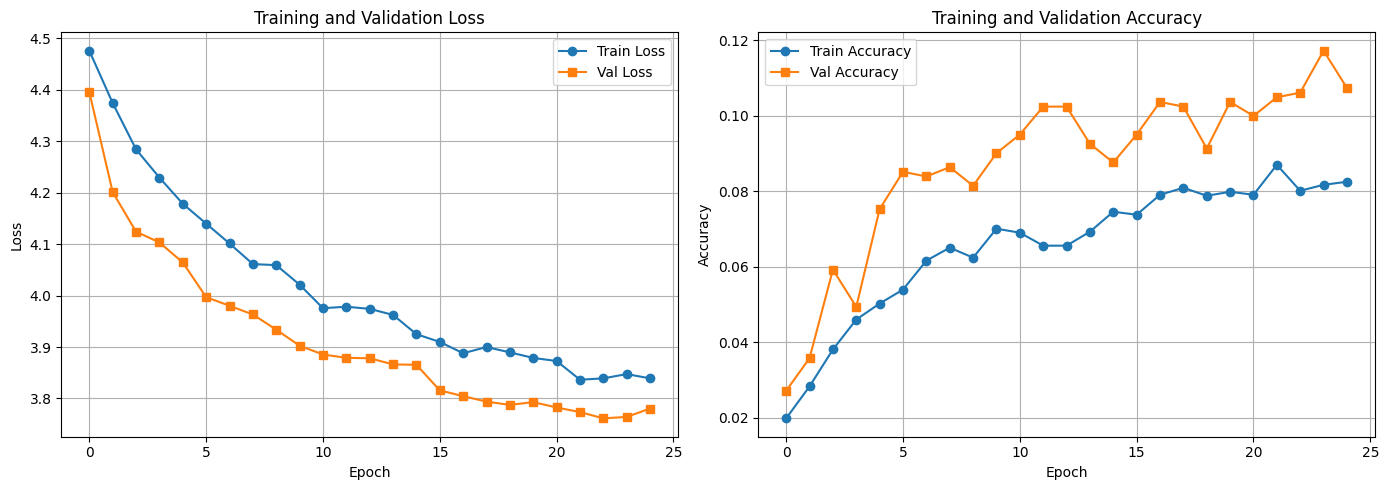

Training history plot saved!


In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

# Accuracy plot
axes[1].plot(history['train_accuracy'], label='Train Accuracy', marker='o')
axes[1].plot(history['val_accuracy'], label='Val Accuracy', marker='s')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved!")

## 7. Test the Model

In [15]:
# Load best model and test
checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
class_names = checkpoint['class_names']

# Test the model
test_loss, test_acc = validate_epoch(model, test_loader, criterion, DEVICE)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

# Per-class accuracy
def evaluate_per_class(model, test_loader, class_names, device):
    """Calculate per-class accuracy"""
    model.eval()
    class_correct = [0] * len(class_names)
    class_total = [0] * len(class_names)
    
    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc='Evaluating'):
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            c = (preds == labels).squeeze()
            for i in range(len(labels)):
                label = labels[i]
                class_correct[label] += c[i].item()
                class_total[label] += 1
    
    return class_correct, class_total

class_correct, class_total = evaluate_per_class(model, test_loader, class_names, DEVICE)

print("\nPer-Class Accuracy:")
print(f"{'Class':<20} {'Accuracy':<10} {'Samples':<10}")
print("-" * 40)
for i, class_name in enumerate(class_names):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        print(f"{class_name:<20} {accuracy:>8.2f}% {class_total[i]:>8}")
    else:
        print(f"{class_name:<20} {'N/A':<10} {0:>8}")

Validating: 100%|██████████| 26/26 [00:33<00:00,  1.30s/it]


Test Loss: 3.7799
Test Accuracy: 0.0938


Evaluating: 100%|██████████| 26/26 [00:09<00:00,  2.82it/s]


Per-Class Accuracy:
Class                Accuracy   Samples   
----------------------------------------
antelope                 0.00%        9
badger                   0.00%        9
bat                     22.22%        9
bear                     0.00%        9
bee                      0.00%        9
beetle                   0.00%        9
bison                    0.00%        9
boar                     0.00%        9
butterfly                0.00%        9
cat                      0.00%        9
caterpillar             66.67%        9
chimpanzee               0.00%        9
cockroach               33.33%        9
cow                      0.00%        9
coyote                   0.00%        9
crab                     0.00%        9
crow                     0.00%        9
deer                     0.00%        9
dog                      0.00%        9
dolphin                 33.33%        9
donkey                   0.00%        9
dragonfly                0.00%        9
duck           

## 8. Inference on Custom Images

Testing inference on random test images...

Image: 1fd6478368.jpg
Predicted: wolf (5.04%)
Top-5 Predictions:
  - wolf: 5.04%
  - otter: 4.95%
  - panda: 4.53%
  - seal: 4.06%
  - gorilla: 4.00%



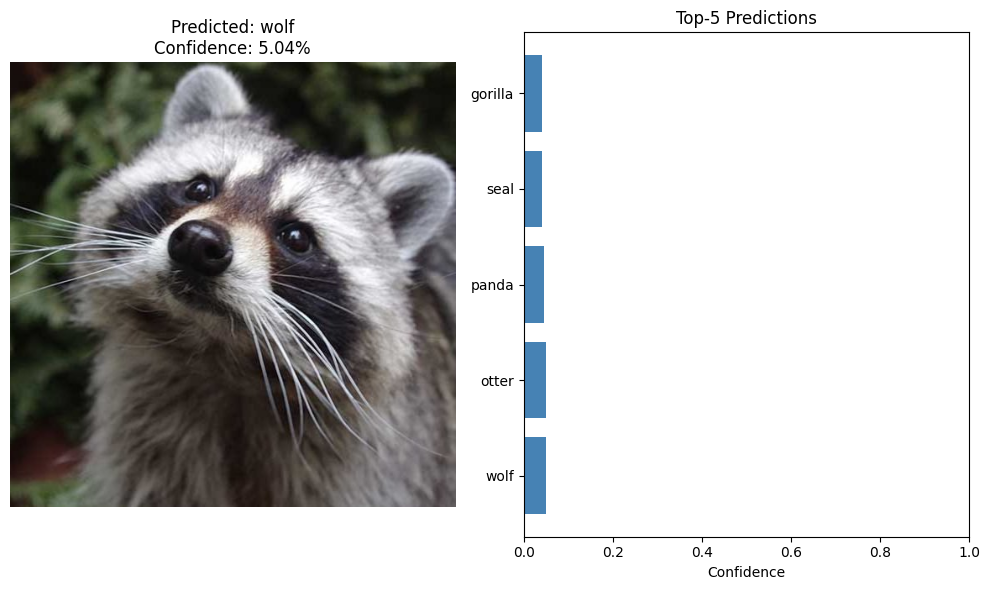

Image: 8a33efacf4.jpg
Predicted: sandpiper (5.86%)
Top-5 Predictions:
  - sandpiper: 5.86%
  - mouse: 4.76%
  - sparrow: 3.88%
  - mosquito: 3.37%
  - fly: 3.12%



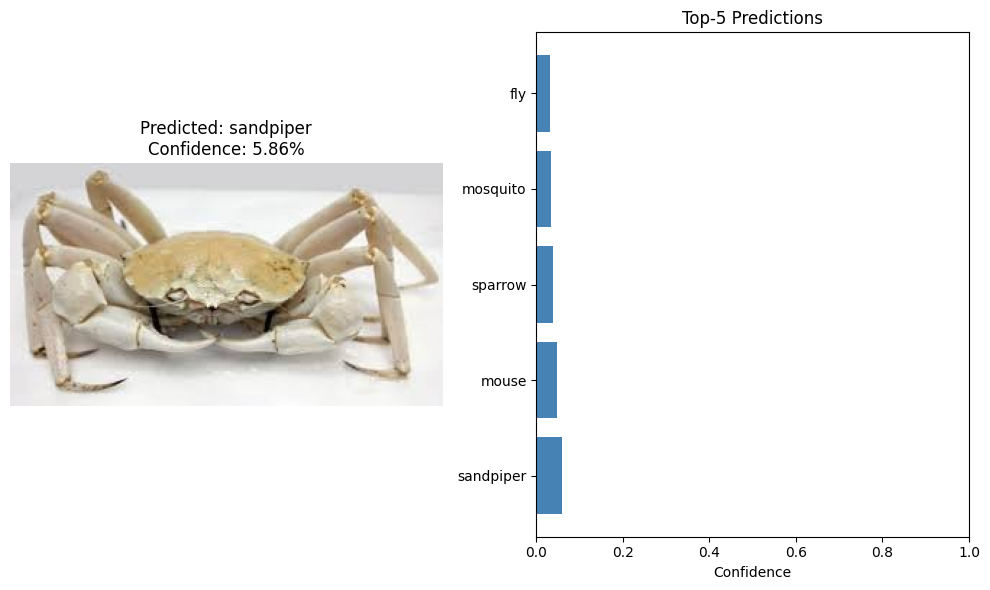

Image: 3d09dc2987.jpg
Predicted: gorilla (6.00%)
Top-5 Predictions:
  - gorilla: 6.00%
  - okapi: 5.35%
  - raccoon: 4.71%
  - boar: 4.69%
  - zebra: 4.41%



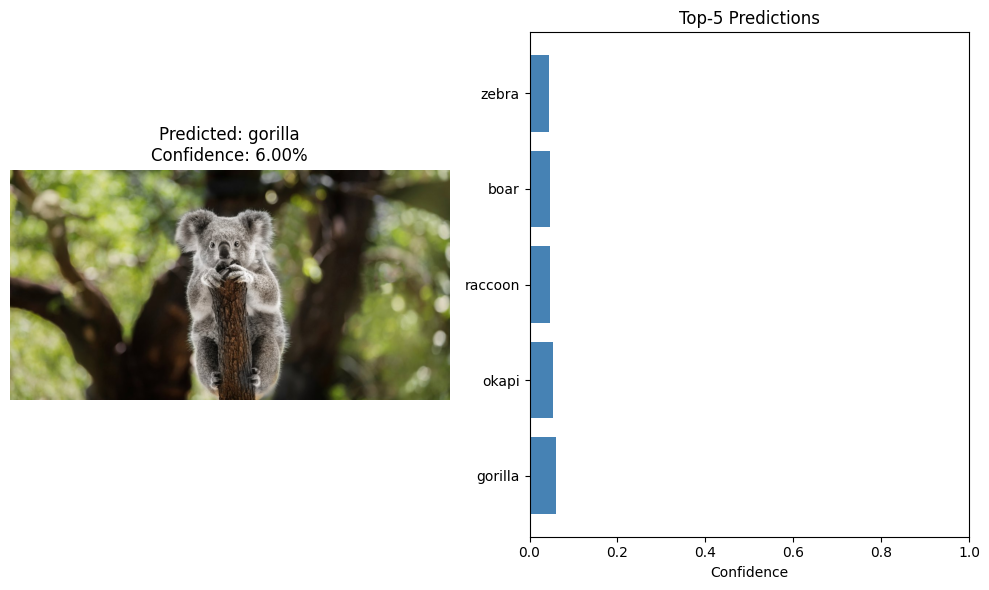

In [16]:
def predict_image(image_path, model, class_names, device, transform=val_test_transforms):
    """Predict class of a single image"""
    model.eval()
    
    # Load and preprocess image
    image = Image.open(image_path).convert('RGB')
    image_tensor = transform(image).unsqueeze(0).to(device)
    
    # Make prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)
        confidence, predicted = torch.max(probabilities, 1)
    
    predicted_class = class_names[predicted.item()]
    confidence_score = confidence.item()
    
    # Get top-5 predictions
    top5_probs, top5_indices = torch.topk(probabilities, 5, dim=1)
    top5_probs = top5_probs[0].cpu().numpy()
    top5_indices = top5_indices[0].cpu().numpy()
    
    return {
        'image': image,
        'predicted_class': predicted_class,
        'confidence': confidence_score,
        'top5_predictions': [(class_names[idx], prob) for idx, prob in zip(top5_indices, top5_probs)]
    }

def visualize_prediction(result, figsize=(10, 6)):
    """Visualize prediction result"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    
    # Display image
    ax1.imshow(result['image'])
    ax1.set_title(f"Predicted: {result['predicted_class']}\nConfidence: {result['confidence']:.2%}")
    ax1.axis('off')
    
    # Display top-5 predictions
    top5_classes = [pred[0] for pred in result['top5_predictions']]
    top5_probs = [pred[1] for pred in result['top5_predictions']]
    
    ax2.barh(top5_classes, top5_probs, color='steelblue')
    ax2.set_xlabel('Confidence')
    ax2.set_title('Top-5 Predictions')
    ax2.set_xlim([0, 1])
    
    plt.tight_layout()
    return fig

# Test inference on random test images
print("Testing inference on random test images...\n")
test_images = list(TEST_DIR.rglob('*.jpg')) + list(TEST_DIR.rglob('*.png')) + list(TEST_DIR.rglob('*.jpeg'))

if test_images:
    num_samples = min(3, len(test_images))
    import random
    sampled_images = random.sample(test_images, num_samples)
    
    for img_path in sampled_images:
        result = predict_image(img_path, model, class_names, DEVICE)
        print(f"Image: {img_path.name}")
        print(f"Predicted: {result['predicted_class']} ({result['confidence']:.2%})")
        print(f"Top-5 Predictions:")
        for pred_class, prob in result['top5_predictions']:
            print(f"  - {pred_class}: {prob:.2%}")
        print()
        
        # Visualize
        fig = visualize_prediction(result)
        plt.show()
else:
    print("No test images found!")

## 9. Save Model and Configuration

In [17]:
# Save model configuration and metadata
config = {
    'num_classes': num_classes,
    'class_names': class_names,
    'image_size': IMAGE_SIZE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'epochs': EPOCHS,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'model_architecture': 'Custom YOLO-Inspired CNN',
    'device': str(DEVICE),
    'train_size': len(train_dataset),
    'val_size': len(val_dataset),
    'test_size': len(test_dataset),
}

config_path = SAVE_DIR / 'model_config.json'
with open(config_path, 'w') as f:
    json.dump(config, f, indent=4)

print(f"Model configuration saved to {config_path}")

# Save final model (not just best)
final_model_path = SAVE_DIR / 'final_model.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
}, final_model_path)

print(f"Final model saved to {final_model_path}")

# Display final statistics
print("\n" + "="*50)
print("TRAINING SUMMARY")
print("="*50)
print(f"Model: Custom YOLO-Inspired CNN")
print(f"Classes: {num_classes}")
print(f"Total Parameters: {trainable_params:,}")
print(f"Training Epochs: {EPOCHS}")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Train Set Size: {len(train_dataset)}")
print(f"Val Set Size: {len(val_dataset)}")
print(f"Test Set Size: {len(test_dataset)}")
print(f"\nModels saved in: {SAVE_DIR}")
print("="*50)

Model configuration saved to models\saved_models\model_config.json
Final model saved to models\saved_models\final_model.pth

TRAINING SUMMARY
Model: Custom YOLO-Inspired CNN
Classes: 90
Total Parameters: 1,746,394
Training Epochs: 25
Best Validation Accuracy: 0.1173
Test Accuracy: 0.0938
Train Set Size: 3780
Val Set Size: 810
Test Set Size: 810

Models saved in: models\saved_models
